In [227]:
"""
This script generates synthetic 2D images of a star-shaped pattern with varying signal-to-noise ratios (SNRs) 
and corresponding ground truth images. The generated data is saved in HDF5 format for further processing 
(e.g., by a convolutional neural network). Additionally, optional TIFF files and an ImageJ macro can be 
generated for visualization and analysis.

Usage:
    Run the notebook directly to generate the synthetic data and save it in the specified formats. 
    Uncomment the optional sections to generate TIFF files and an ImageJ macro.
    - The random number generator is fixed with a seed for repeatable executions.
    - The script assumes the working directory is writable for saving the output files.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import h5py
from scipy.signal import fftconvolve, convolve2d
from scipy.optimize import leastsq
import scipy.ndimage as ndi
import cv2
from tqdm.notebook import tqdm


# Fix random number generator for repeatable executions
RNG = np.random.default_rng(seed=20250113)

# ------------ Data generation parameters  --------------
PSFW = 3
WIDTH = 50
HEIGTH = 50
BCKG = 100 #100
STD = 13 #13
UPSCALE = 4
DEG = np.pi/180.
THETA_STEP = 120*DEG

# ------------ Helper functions  --------------
def norm(img):
    _img = img - np.min(img)
    return _img/np.sum(_img)


def gauss_2d(xy, amplitude, xo, yo, sigma_x, sigma_y, theta, offset):
    """
    Computes a 2D Gaussian function.

    Parameters:
        xy (tuple of ndarray): A tuple containing two 2D arrays (x, y) representing the grid coordinates.
        amplitude (float): The amplitude (peak value) of the Gaussian function.
        xo (float): The x-coordinate of the center of the Gaussian.
        yo (float): The y-coordinate of the center of the Gaussian.
        sigma_x (float): The standard deviation of the Gaussian in the x-direction.
        sigma_y (float): The standard deviation of the Gaussian in the y-direction.
        theta (float): The rotation angle of the Gaussian in radians.
        offset (float): The constant offset added to the Gaussian function.

    Returns:
        ndarray: A 1D array representing the raveled 2D Gaussian function values.
        It need to be reshaped to form a 2D array.
    """
    x, y = xy
    xo = float(xo)
    yo = float(yo)
    a = (np.cos(theta)**2)/(2*sigma_x**2) + (np.sin(theta)**2)/(2*sigma_y**2)
    b = -(np.sin(2*theta))/(4*sigma_x**2) + (np.sin(2*theta))/(4*sigma_y**2)
    c = (np.sin(theta)**2)/(2*sigma_x**2) + (np.cos(theta)**2)/(2*sigma_y**2)
    g = offset + amplitude*np.exp(- (a*((x-xo)**2) + 2*b*(x-xo)*(y-yo)
                                     + c*((y-yo)**2)))
    return g.ravel()


def generate_image(xyi, noise_mean, noise_std, psf_width, h, w):
    """
    Generates a 2D image with Gaussian point sources and added noise.

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains 
            (x, y, intensity) representing the coordinates and intensity 
            of a point source.
        noise_mean (float): The mean of the Gaussian noise to be added to the image.
        noise_std (float): The standard deviation of the Gaussian noise.
        psf_width (float): The width of the point spread function (PSF) for the Gaussian sources.
        h (int): The height of the generated image.
        w (int): The width of the generated image.

    Returns:
        numpy.ndarray: A 2D array representing the generated image, normalized 
        such that all pixel values sum to 1.
    """
    # img = np.clip(RNG.normal(noise_mean, noise_std,
    #               h*w).reshape(h, w), 0, None)
    img = RNG.normal(noise_mean, noise_std,
                   h*w).reshape(h, w)
    ys = np.arange(h)
    xs = np.arange(w)
    xy = np.meshgrid(xs, ys)
    for x, y, intensity in xyi:
        img += gauss_2d(xy, intensity, x, y, psf_width,
                        psf_width, 0, 0).reshape((h, w))
    # img = (img - np.min(img))
    # img = img/np.sum(img)
    return img


def generate_gt_image(xyi, h, w):
    """
    Generate a ground truth image by placing intensities at specified coordinates.

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains three values 
                              (x, y, intensity). `x` and `y` are the coordinates, and 
                              `intensity` is the value to be added at that position.
        h (int): The height of the output image.
        w (int): The width of the output image.

    Returns:
        numpy.ndarray: A 2D array of shape (h, w) representing the generated image, 
                       normalized such that the sum of all pixel values equals 1.

    Notes:
        - The function rounds the `x` and `y` coordinates to the nearest integer 
          to determine the pixel location.
        - If the rounded coordinates fall outside the image dimensions, they are ignored.
        - The resulting image is normalized by dividing all pixel values by the total sum.
    """
    img = np.zeros((h, w))
    for x, y, intensity in xyi:
        x_nearest = int(np.round(x))
        y_nearest = int(np.round(y))
        if (x_nearest <= w-1) and (y_nearest <= h-1):
            img[y_nearest, x_nearest] += intensity
    return img/np.sum(img)


def upscale_xyi(xyi, scale=4):
    """
    Upscales the x and y coordinates of a list of [x, y, i] elements by a given scale factor.

    This function takes a list of [x, y, i] elements, where x and y are coordinates and i is an 
    additional value, and scales the x and y coordinates by the specified scale factor. A shift 
    is applied to center the scaled coordinates.

    Args:
        xyi (list of lists or tuples): A list of [x, y, i] elements to be upscaled.
        scale (int, optional): The scale factor to upscale the x and y coordinates. Defaults to 4.

    Returns:
        list: A list of upscaled [x, y, i] elements with the same structure as the input.
    """
    xyiarr = np.array(xyi)
    shift = (scale-1)/2
    xyiarr[:, 0] = xyiarr[:, 0]*scale + shift
    xyiarr[:, 1] = xyiarr[:, 1]*scale + shift
    return list(xyiarr)

In [228]:
# Generate coordinates of the star-shaped pattern.
xys = np.array([(25, 25)]+[(r*np.cos(THETA_STEP*i)+25, r*np.sin(THETA_STEP*i)+25)
               for i in range(3) for r in [10, ]])

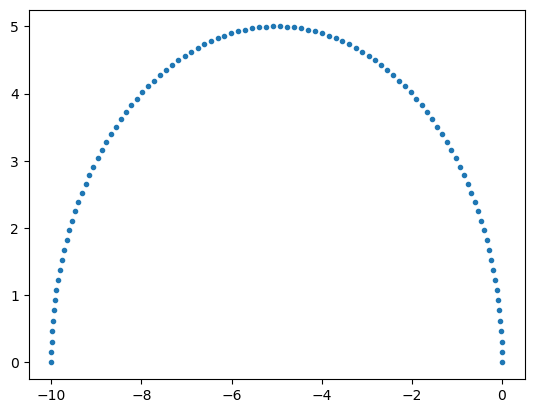

In [229]:
n_drifting_frames = 101

t_param = np.linspace(0, np.pi, n_drifting_frames+1)
R_drift = 5
drift_offset = np.vstack([(np.cos(t_param)-1)*R_drift, R_drift*np.sin(t_param)]).T

plt.plot(drift_offset[:,0], drift_offset[:,1],".")

In [230]:
snr = 1_000_000
stack_noiseless = []
stack_for_cnn = []
for x0, y0 in drift_offset:
    _xys = xys + np.array((x0, y0))
    snr_col = np.hstack([_xys, np.ones((xys.shape[0], 1))*snr])
    # Recalculate coordinates for a 4-times finer grid.
    xyi = np.array(upscale_xyi(snr_col, scale=UPSCALE))
    # Synthetic data (images) for testing
    stack_for_cnn.append(generate_image(snr_col, BCKG, STD, PSFW, HEIGTH, WIDTH))
    # Corresponding reference images
    stack_noiseless.append(generate_gt_image(upscale_xyi(snr_col, scale=UPSCALE), HEIGTH*UPSCALE, WIDTH*UPSCALE))

np.save('rs-s-drift-test-in.npy', stack_for_cnn)

#after this, put the output into CFCNN, come back with output

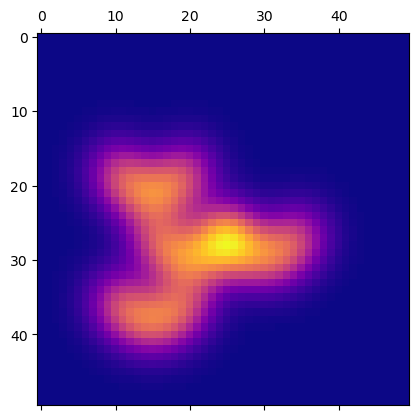

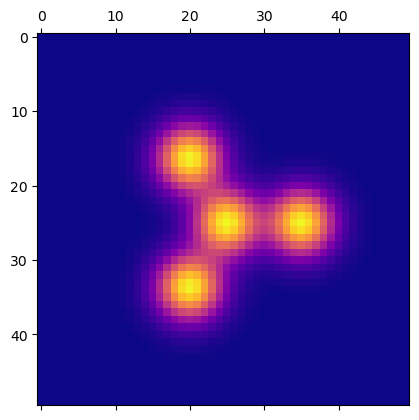

In [231]:
plt.matshow(np.sum(stack_for_cnn, axis=0))
plt.show()
plt.matshow(stack_for_cnn[0])
plt.show()

(102, 200, 200)


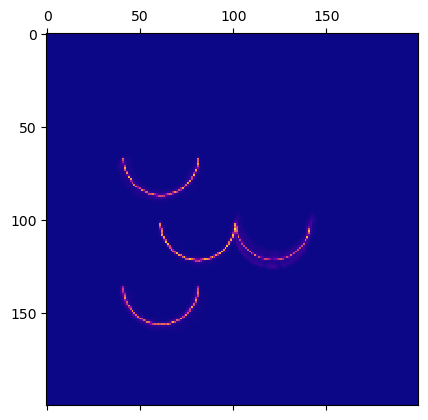

In [233]:
cnnout = np.load('temp_cfcnn_out.npy')
print(cnnout.shape)
plt.matshow(np.sum(cnnout, axis=0))

In [234]:
#borrowed from https://piscat.readthedocs.io/_modules/piscat/Localization/radial_symmetry_centering.html#RadialCenter
def radialcenter(Image):
    Image = Image.astype(np.float64)
    Nx = Image.shape[0]
    Ny = Image.shape[1]

    xm_onerow = np.arange(-((Nx - 1) / 2.0) + 0.5, ((Nx - 1) / 2.0) + 0.5, 1, dtype=np.int64)
    xm = np.broadcast_to(xm_onerow, (Nx - 1, Ny - 1))

    ym_onecol = np.arange(-((Ny - 1) / 2.0) + 0.5, ((Ny - 1) / 2.0) + 0.5, dtype=np.int64)
    ym = np.transpose(np.broadcast_to(ym_onecol, (Nx - 1, Ny - 1)))

    dIdu = Image[0 : Ny - 1, 1:Nx] - Image[1:Ny, 0 : Nx - 1]
    dIdv = Image[0 : Ny - 1, 0 : Nx - 1] - Image[1:Ny, 1:Nx]

    h = (1 / 9) * np.ones((3, 3))
    fdu = convolve2d(dIdu, h, mode="same")
    fdv = convolve2d(dIdv, h, mode="same")
    dImag2 = np.multiply(fdu, fdu) + np.multiply(fdv, fdv)

    m = -np.divide((fdv + fdu), (fdu - fdv))

    NNanm = np.sum(np.isnan(m))
    if NNanm > 0:
        unsmoothm = np.divide((dIdv + dIdu), (dIdu - dIdv))
        m[np.isnan(m)] = unsmoothm[np.isnan(m)]

    NNanm = np.sum(np.isnan(m))
    if NNanm > 0:
        m[np.isnan(m)] = 0

    try:
        m[np.isinf(m)] = 10 * np.max(m[~np.isinf(m)])
    except:
        m = np.divide((dIdv + dIdu), (dIdu - dIdv))

    b = ym - np.multiply(m, xm)
    sdI2 = np.sum(dImag2)
    xcentroid = np.sum(np.sum(np.multiply(dImag2, xm))) / sdI2
    ycentroid = np.sum(np.sum(np.multiply(dImag2, ym))) / sdI2
    w = np.divide(
        dImag2,
        np.sqrt(
            np.multiply((xm - xcentroid), (xm - xcentroid))
            + np.multiply((ym - ycentroid), (ym - ycentroid))
        ),
    )

    xc, yc = lsradialcenterfit(m, b, w)

    xc = xc + (Nx + 1) / 2.0
    yc = yc + (Ny + 1) / 2.0

    Isub = Image - np.min(Image)
    x = np.linspace(0, Nx - 1, Nx, dtype=np.int64)
    y = np.linspace(0, Ny - 1, Ny, dtype=np.int64)
    px, py = np.meshgrid(x, y)
    xoffset = px - xc
    yoffset = py - yc
    r2 = np.multiply(xoffset, xoffset) + np.multiply(yoffset, yoffset)
    sigma = np.sqrt(np.sum(np.sum(np.multiply(Isub, r2))) / np.sum(Isub)) / 2

    return xc, yc, sigma

def lsradialcenterfit(m, b, w):
    wm2p1 = np.divide(w, np.multiply(m, m) + 1)
    sw = np.sum(wm2p1)
    smmw = np.sum(np.multiply(m, np.multiply(m, wm2p1)))
    smw = np.sum(np.multiply(m, wm2p1))
    smbw = np.sum(np.multiply(m, np.multiply(b, wm2p1)))
    sbw = np.sum(np.multiply(b, wm2p1))
    det = smw * smw - smmw * sw
    xc = (smbw * sw - smw * sbw) / det
    yc = (smbw * smw - smmw * sbw) / det
    return xc, yc

def crosscorrfft(a,b):
    return fftconvolve(a, b[::-1, ::-1])

def assess_drift(frm_new, frm_ref):
    #note - detects the drift in units of *upscaled* pixels
    h, w = frm_new.shape
    cc = crosscorrfft(frm_new, frm_ref)
    cc /= np.max(cc)
    ch, cw = cc.shape
    imx = np.argmax(ndi.gaussian_filter(cc,1))
    irow = imx // cw
    icol = imx % cw    

    span = 16
    ccsub = cc[irow - span : irow + span, icol - span : icol + span]

    # params = fitgaussian(ccsub)
    # height, y, x, width_x, width_y = params
    x, y, s = radialcenter(ccsub)
    xa = icol - span + x
    ya = irow - span + y
    dx = xa - (cc.shape[1]/2) - 0.5
    dy = ya - (cc.shape[1]/2) - 0.5
    # print(irow, icol, cc[irow, icol], y, x, cc.shape)
    # plt.matshow(ndi.gaussian_filter(cc,1))
    # plt.plot([icol], [irow], 'rx')
    # plt.plot([icol - span + x -1], [irow - span + y - 1], 'r+')
    # plt.plot([h], [w], 'w.')
    # rect = Rectangle((icol - span, irow - span), 2*span, 2*span, facecolor='none', edgecolor='red')
    # plt.gca().add_artist(rect)
    # # plt.xlim(icol-2*span, icol+2*span)
    # # plt.ylim(irow-2*span, irow+2*span)
    # plt.show()
    return dx, dy

In [214]:
%matplotlib inline
dxy = np.array([assess_drift(img, cnnout[0]) for img in cnnout])


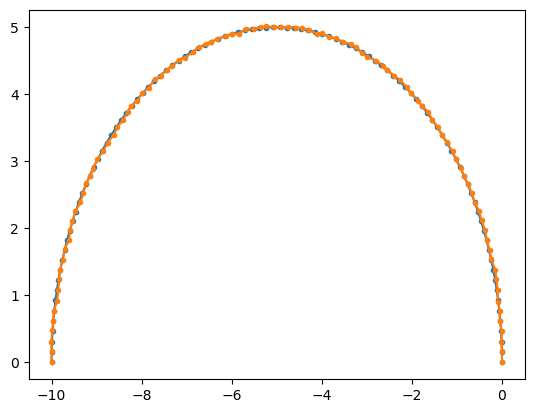

In [235]:

plt.plot(drift_offset[:,0], drift_offset[:,1], ".-")
plt.plot((dxy[:,0]/4), (dxy[:,1]/4), ".-")
# plt.plot((noisy_drift_res[:,0])/4, (noisy_drift_res[:,1])/4, ".-")

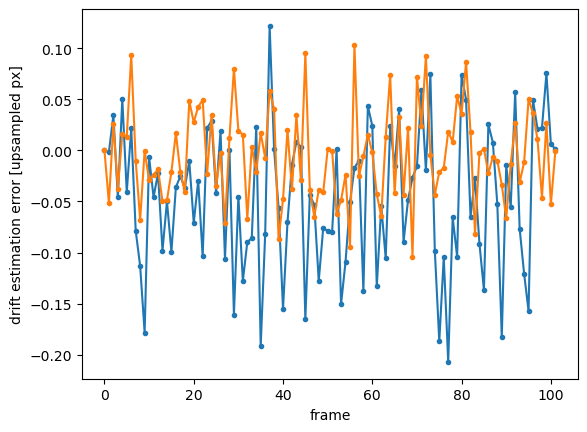

In [236]:
xerr = drift_offset[:,0] - dxy[:,0]/4
yerr = drift_offset[:,1] - dxy[:,1]/4
plt.plot(xerr*4, ".-", label='x')
plt.plot(yerr*4, ".-", label="y")
plt.ylabel('drift estimation error [upsampled px]')
plt.xlabel('frame')
plt.show()

In [237]:
def correct_drict(img, dx, dy):
    #note: use dx, dy in units of *upscaled* pixels, they are detected drift values and the image will be shifted backward
    h, w = img.shape
    mat = np.array([[1,0,-dx],[0,1,-dy]])
    return cv2.warpAffine(img, mat, (h,w))

In [238]:
imgcor = np.array([correct_drict(img, dx, dy) for img, (dx, dy) in tqdm(zip(cnnout, dxy), total=len(cnnout))])
imgcorperf = np.array([correct_drict(img, dx, dy) for img, (dx, dy) in tqdm(zip(cnnout, drift_offset*4), total=len(cnnout))])

  0%|          | 0/102 [00:00<?, ?it/s]

  0%|          | 0/102 [00:00<?, ?it/s]

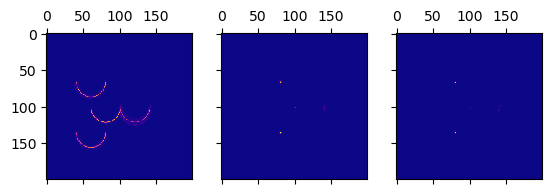

In [239]:
fig, ax = plt.subplots(1,3, sharex=True, sharey=True)
ax[0].matshow(np.sum(cnnout, axis=0))
ax[1].matshow(np.sum(imgcor, axis=0))
ax[2].matshow(cnnout[0])
plt.show()

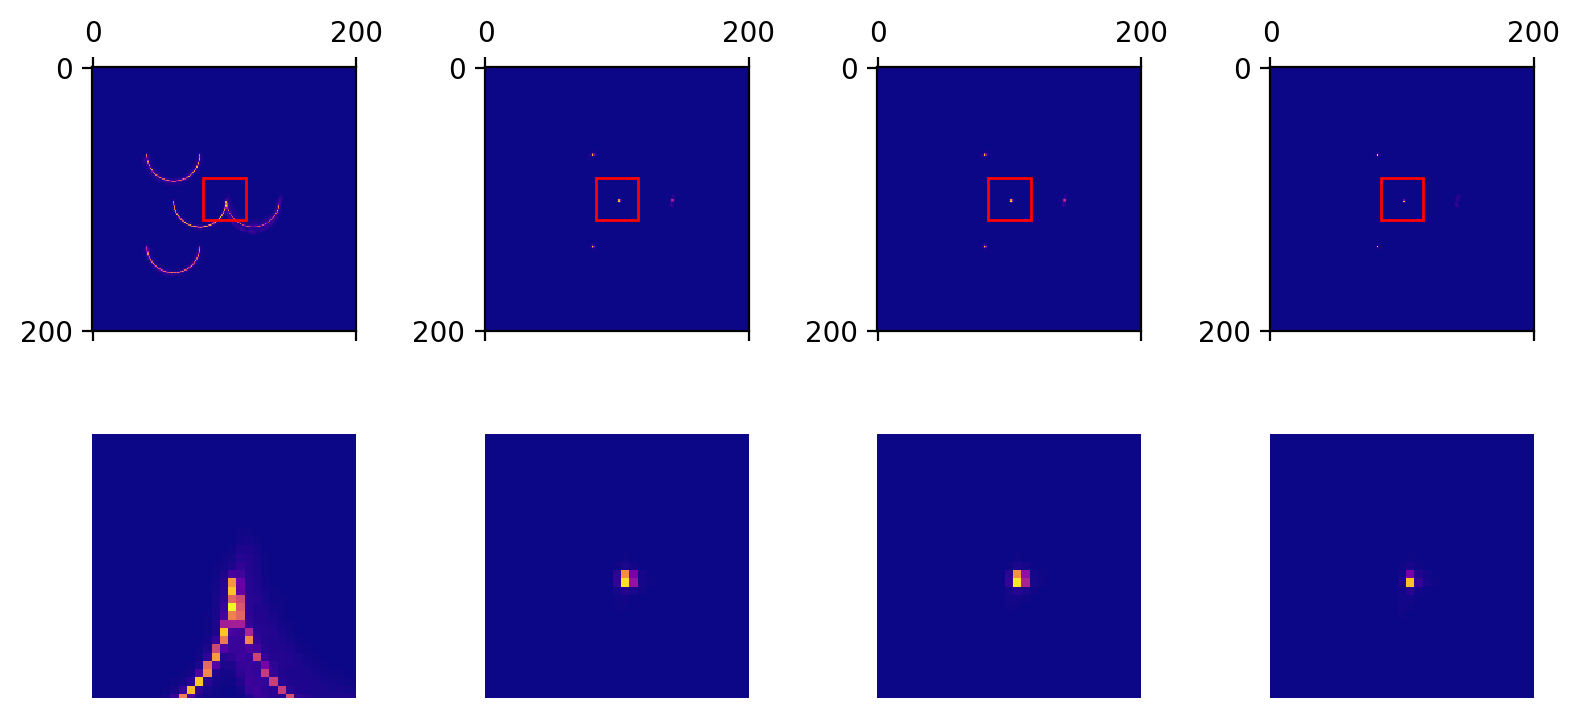

In [240]:
%matplotlib inline
fig, ax = plt.subplots(2,4, figsize=(8,4), dpi=200)
cm = plt.set_cmap('plasma')
ax[0,0].matshow(np.sum(cnnout, axis=0))
ax[0,1].matshow(np.sum(imgcor, axis=0))
ax[0,2].matshow(np.sum(imgcorperf, axis=0))
ax[0,3].matshow(cnnout[0])
ax[1,0].matshow(np.sum(cnnout, axis=0))
ax[1,1].matshow(np.sum(imgcor, axis=0))
ax[1,2].matshow(np.sum(imgcorperf, axis=0))
ax[1,3].matshow(cnnout[0])
x0, y0 = 100, 100
for i in range(4):
    ax[1,i].set_xlim(x0-16,x0+16)
    ax[1,i].set_ylim(y0+16, y0-16)
    rect = Rectangle((x0-16, y0-16), 32, 32, facecolor='none', edgecolor='red')
    ax[0,i].add_artist(rect)
    ax[1,i].set_axis_off()
    ax[0,i].set_xticks([0,200])
    ax[0,i].set_yticks([0,200])

plt.tight_layout()
plt.show()

In [242]:
(32*1024/3)/60

182.04444444444442